# Portfolio Profit Testing - Improved Version

This notebook provides an improved, more readable version of portfolio profit testing using the Markowitz Model with the following features:

## Key Improvements:
1. **Modular Design**: Functions are separated for reusability
2. **Configurable Parameters**: Easy to adjust settings in one place
3. **Better Documentation**: Clear explanations for each step
4. **Error Handling**: Robust data validation
5. **Visualization**: Enhanced charts and summaries
6. **Performance Tracking**: Detailed profit analysis

## Workflow:
1. Set configuration parameters
2. Load and filter stock data
3. Create optimized portfolio using Markowitz Model
4. Test portfolio performance over specified periods
5. Generate comprehensive reports and visualizations

## Configuration Parameters

**Adjust these parameters to customize your analysis:**

In [10]:
# =============================================================================
# CONFIGURATION PARAMETERS - ADJUST THESE AS NEEDED
# =============================================================================

# Portfolio Configuration
CONFIG = {
    # Stock Selection
    'current_year': 2025,
    'initial_capital': 30_000_000,  # 30 million IDR
    
    # Data Collection Parameters
    'training_period_months': 12,  # Months of data for portfolio optimization
    'testing_period_months': 24,   # Months to test portfolio performance
    
    # Portfolio Optimization
    'min_mean_return': 0.0,        # Minimum required mean return (0 = any positive)
    'max_weight_per_stock': 1.0,   # Maximum weight per stock (1.0 = 100%)
    'min_weight_per_stock': 0.0,   # Minimum weight per stock
    
    # Testing Configuration
    'test_start_year': 2018,       # First year to start testing
    'test_end_year': 2022,         # Last year to test
    'lot_size': 100,               # Indonesian stock lot size
    
    # Output Settings
    'save_results': False,          # Save results to CSV
    'show_plots': True,            # Display visualization
    'verbose': True                # Print detailed information
}

print("Configuration loaded successfully!")
print(f"Testing period: {CONFIG['test_start_year']} - {CONFIG['test_end_year']}")
print(f"Initial capital: IDR {CONFIG['initial_capital']:,}")

Configuration loaded successfully!
Testing period: 2018 - 2022
Initial capital: IDR 30,000,000


## Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
from datetime import datetime, timedelta
from typing import List, Dict, Tuple, Optional
import os

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Stock Universe Definition

In [11]:
# Indonesia Blue Chip Stocks (IDX30 and major stocks)
INDONESIA_BLUECHIP = [
    'BBCA.JK',  # Bank Central Asia
    'BBRI.JK',  # Bank Rakyat Indonesia  
    'BMRI.JK',  # Bank Mandiri
    'BBNI.JK',  # Bank Negara Indonesia
    'ASII.JK',  # Astra International
    'UNVR.JK',  # Unilever Indonesia
    'TLKM.JK',  # Telkom Indonesia
    'GGRM.JK',  # Gudang Garam
    'INCO.JK',  # Vale Indonesia
    'ANTM.JK',  # Aneka Tambang
    'ADRO.JK',  # Adaro Energy
    'SMGR.JK',  # Semen Indonesia
    'ICBP.JK',  # Indofood CBP
    'KLBF.JK',  # Kalbe Farma
    'CPIN.JK',  # Charoen Pokphand Indonesia
    'INTP.JK',  # Indocement
    'EXCL.JK',  # XL Axiata
    'PGAS.JK',  # Perusahaan Gas Negara
    'PTBA.JK',  # Bukit Asam
    'JSMR.JK',  # Jasa Marga
    'WSKT.JK',  # Waskita Karya
    'WIKA.JK',  # Wijaya Karya
    'PTPP.JK',  # Pembangunan Perumahan
    'TOWR.JK',  # Sarana Menara Nusantara
    'BSDE.JK',  # Bumi Serpong Damai
    'PWON.JK',  # Pakuwon Jati
    'CTRA.JK',  # Ciputra Development
    'ERAA.JK',  # Erajaya Swasembada
    'MNCN.JK',  # Media Nusantara Citra
    'SIDO.JK'   # Industri Jamu dan Farmasi Sido Muncul
]

print(f"Stock universe defined: {len(INDONESIA_BLUECHIP)} stocks")
print("Sample stocks:", INDONESIA_BLUECHIP[:5])

Stock universe defined: 30 stocks
Sample stocks: ['BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK', 'ASII.JK']


## Utility Functions

In [12]:
def get_stock_data(stocks: List[str], start_date: str, end_date: str, 
                   interval: str = '1mo') -> pd.DataFrame:
    """
    Download stock data and calculate log returns.
    
    Parameters:
    -----------
    stocks : List[str]
        List of stock tickers
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    interval : str
        Data frequency ('1mo', '1d', etc.)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with log returns for each stock
    """
    if CONFIG['verbose']:
        print(f"Downloading data from {start_date} to {end_date}...")
    
    returns_df = pd.DataFrame()
    
    for stock in stocks:
        try:
            # Download stock data
            ticker = yf.Ticker(stock)
            hist = ticker.history(start=start_date, end=end_date, 
                                interval=interval, actions=False)
            
            if len(hist) > 1:  # Need at least 2 data points for returns
                # Calculate log returns
                log_returns = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
                returns_df[stock] = log_returns
                
        except Exception as e:
            if CONFIG['verbose']:
                print(f"Warning: Could not download {stock}: {e}")
            continue
    
    # Remove stocks with insufficient data
    returns_df = returns_df.dropna(axis=1)
    
    if CONFIG['verbose']:
        print(f"Successfully downloaded {len(returns_df.columns)} stocks")
    
    return returns_df


def filter_positive_returns(returns_df: pd.DataFrame) -> List[str]:
    """
    Filter stocks with positive mean returns.
    
    Parameters:
    -----------
    returns_df : pd.DataFrame
        DataFrame with stock returns
    
    Returns:
    --------
    List[str]
        List of stocks with positive mean returns
    """
    mean_returns = returns_df.mean()
    positive_stocks = mean_returns[mean_returns > CONFIG['min_mean_return']].index.tolist()
    
    if CONFIG['verbose']:
        print(f"Filtered to {len(positive_stocks)} stocks with positive returns")
    
    return positive_stocks


print("Utility functions defined successfully!")

Utility functions defined successfully!


## Portfolio Optimization Functions

In [13]:
def optimize_portfolio(returns_df: pd.DataFrame) -> Tuple[np.ndarray, Dict]:
    """
    Optimize portfolio using Markowitz mean-variance optimization.
    
    Parameters:
    -----------
    returns_df : pd.DataFrame
        DataFrame with stock returns
    
    Returns:
    --------
    Tuple[np.ndarray, Dict]
        Optimal weights and portfolio statistics
    """
    # Calculate expected returns and covariance matrix
    mu = returns_df.mean().values
    cov_matrix = returns_df.cov().values
    n_assets = len(mu)
    
    # Objective function: minimize portfolio variance
    def objective(weights):
        return np.dot(weights, np.dot(cov_matrix, weights))
    
    # Constraints: weights sum to 1
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    ]
    
    # Bounds: each weight between min and max
    bounds = tuple((CONFIG['min_weight_per_stock'], CONFIG['max_weight_per_stock']) 
                  for _ in range(n_assets))
    
    # Initial guess: equal weights
    initial_guess = np.array([1.0/n_assets] * n_assets)
    
    # Optimize
    result = minimize(objective, initial_guess, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
    
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")
    
    optimal_weights = result.x
    
    # Calculate portfolio statistics
    portfolio_return = np.dot(optimal_weights, mu)
    portfolio_risk = np.sqrt(np.dot(optimal_weights, np.dot(cov_matrix, optimal_weights)))
    
    stats = {
        'expected_return': portfolio_return,
        'risk': portfolio_risk,
        'sharpe_ratio': portfolio_return / portfolio_risk if portfolio_risk > 0 else 0,
        'weights_sum': np.sum(optimal_weights)
    }
    
    if CONFIG['verbose']:
        print(f"Portfolio optimized successfully!")
        print(f"Expected monthly return: {portfolio_return*100:.3f}%")
        print(f"Monthly risk (volatility): {portfolio_risk*100:.3f}%")
        print(f"Sharpe ratio: {stats['sharpe_ratio']:.3f}")
    
    return optimal_weights, stats


def create_portfolio_allocation(weights: np.ndarray, stocks: List[str], 
                               capital: float) -> pd.DataFrame:
    """
    Create portfolio allocation with lot sizes and actual spending.
    
    Parameters:
    -----------
    weights : np.ndarray
        Optimal portfolio weights
    stocks : List[str]
        List of stock tickers
    capital : float
        Available capital
    
    Returns:
    --------
    pd.DataFrame
        Portfolio allocation details
    """
    # Filter out zero weights
    non_zero_mask = weights > 1e-6
    active_weights = weights[non_zero_mask]
    active_stocks = [stocks[i] for i in range(len(stocks)) if non_zero_mask[i]]
    
    if len(active_stocks) == 0:
        raise ValueError("No stocks with significant allocation found")
    
    # Get current prices
    current_prices = {}
    for stock in active_stocks:
        try:
            ticker = yf.Ticker(stock)
            hist = ticker.history(period='1d', interval='1d')
            current_prices[stock] = hist['Close'].iloc[-1]
        except:
            if CONFIG['verbose']:
                print(f"Warning: Could not get current price for {stock}")
            current_prices[stock] = 1000  # Default price
    
    # Calculate allocation
    allocation_data = []
    total_spent = 0
    
    for i, stock in enumerate(active_stocks):
        weight = active_weights[i]
        target_value = capital * weight
        price_per_lot = current_prices[stock] * CONFIG['lot_size']
        lots = int(target_value / price_per_lot)
        actual_value = lots * price_per_lot
        total_spent += actual_value
        
        allocation_data.append({
            'Stock': stock,
            'Weight': weight,
            'Target_Value': target_value,
            'Price_Per_Share': current_prices[stock],
            'Price_Per_Lot': price_per_lot,
            'Lots': lots,
            'Actual_Value': actual_value,
            'Actual_Weight': actual_value / capital if capital > 0 else 0
        })
    
    allocation_df = pd.DataFrame(allocation_data)
    
    if CONFIG['verbose']:
        print(f"\nPortfolio Allocation:")
        print(f"Total capital: IDR {capital:,.0f}")
        print(f"Total invested: IDR {total_spent:,.0f}")
        print(f"Cash remaining: IDR {capital - total_spent:,.0f}")
        print(f"Utilization: {total_spent/capital*100:.1f}%")
    
    return allocation_df


print("Portfolio optimization functions defined successfully!")

Portfolio optimization functions defined successfully!


## Profit Testing Functions

In [14]:
def test_portfolio_performance(allocation_df: pd.DataFrame, 
                              test_start: str, test_end: str) -> pd.DataFrame:
    """
    Test portfolio performance over a specified period.
    
    Parameters:
    -----------
    allocation_df : pd.DataFrame
        Portfolio allocation with lots and values
    test_start : str
        Test period start date
    test_end : str
        Test period end date
    
    Returns:
    --------
    pd.DataFrame
        Monthly performance results
    """
    stocks = allocation_df['Stock'].tolist()
    lots = allocation_df['Lots'].tolist()
    
    # Download test period data
    test_data = {}
    for stock in stocks:
        try:
            ticker = yf.Ticker(stock)
            hist = ticker.history(start=test_start, end=test_end, 
                                interval='1mo', actions=False)
            test_data[stock] = hist[['Open', 'Close']]
        except Exception as e:
            if CONFIG['verbose']:
                print(f"Warning: Could not get test data for {stock}: {e}")
            continue
    
    if not test_data:
        raise ValueError("No test data available")
    
    # Calculate monthly performance
    performance_data = []
    
    # Get common date range
    all_dates = None
    for stock_data in test_data.values():
        if all_dates is None:
            all_dates = stock_data.index
        else:
            all_dates = all_dates.intersection(stock_data.index)
    
    for i, date in enumerate(all_dates[1:], 1):  # Skip first month
        prev_date = all_dates[i-1]
        
        total_buy_value = 0
        total_sell_value = 0
        
        for j, stock in enumerate(stocks):
            if stock in test_data:
                try:
                    buy_price = test_data[stock].loc[prev_date, 'Close']
                    sell_price = test_data[stock].loc[date, 'Close']
                    
                    stock_lots = lots[j]
                    buy_value = buy_price * stock_lots * CONFIG['lot_size']
                    sell_value = sell_price * stock_lots * CONFIG['lot_size']
                    
                    total_buy_value += buy_value
                    total_sell_value += sell_value
                except KeyError:
                    continue
        
        if total_buy_value > 0:
            monthly_return = (total_sell_value - total_buy_value) / total_buy_value
            performance_data.append({
                'Date': date,
                'Buy_Value': total_buy_value,
                'Sell_Value': total_sell_value,
                'Profit': total_sell_value - total_buy_value,
                'Return': monthly_return
            })
    
    performance_df = pd.DataFrame(performance_data)
    
    if CONFIG['verbose'] and len(performance_df) > 0:
        avg_return = performance_df['Return'].mean()
        total_return = (1 + performance_df['Return']).prod() - 1
        print(f"\nTest Period Performance:")
        print(f"Average monthly return: {avg_return*100:.2f}%")
        print(f"Total return: {total_return*100:.2f}%")
        print(f"Number of months: {len(performance_df)}")
    
    return performance_df


def run_backtesting(start_year: int, end_year: int) -> pd.DataFrame:
    """
    Run comprehensive backtesting over multiple years.
    
    Parameters:
    -----------
    start_year : int
        First year to test
    end_year : int
        Last year to test
    
    Returns:
    --------
    pd.DataFrame
        Summary of all test results
    """
    all_results = []
    
    for year in range(start_year, end_year + 1):
        try:
            if CONFIG['verbose']:
                print(f"\n{'='*50}")
                print(f"Testing year {year}")
                print(f"{'='*50}")
            
            # Data collection period (previous year)
            data_start = f"{year-1}-12-01"
            data_end = f"{year+1}-12-01"
            
            # Get training data
            returns_df = get_stock_data(INDONESIA_BLUECHIP, data_start, data_end)
            
            if len(returns_df) == 0:
                print(f"No data available for year {year}")
                continue
            
            # Filter stocks with positive returns
            positive_stocks = filter_positive_returns(returns_df)
            
            if len(positive_stocks) < 2:
                print(f"Insufficient stocks with positive returns for year {year}")
                continue
            
            filtered_returns = returns_df[positive_stocks]
            
            # Optimize portfolio
            weights, stats = optimize_portfolio(filtered_returns)
            
            # Create allocation
            allocation_df = create_portfolio_allocation(weights, positive_stocks, 
                                                       CONFIG['initial_capital'])
            
            # Test performance
            test_start = f"{year+2}-12-31"
            test_end = f"{year+4}-01-01"
            
            performance_df = test_portfolio_performance(allocation_df, test_start, test_end)
            
            if len(performance_df) > 0:
                avg_return = performance_df['Return'].mean()
                total_return = (1 + performance_df['Return']).prod() - 1
                volatility = performance_df['Return'].std()
                
                all_results.append({
                    'Year': year,
                    'Test_Year': year + 3,
                    'Num_Stocks': len(positive_stocks),
                    'Portfolio_Stocks': len(allocation_df),
                    'Expected_Return': stats['expected_return'],
                    'Expected_Risk': stats['risk'],
                    'Avg_Monthly_Return': avg_return,
                    'Total_Return': total_return,
                    'Volatility': volatility,
                    'Sharpe_Ratio': avg_return / volatility if volatility > 0 else 0,
                    'Num_Test_Months': len(performance_df)
                })
                
                # Save individual year results
                if CONFIG['save_results']:
                    performance_df.to_csv(f'Profit_Test_{year}.csv', index=False)
                    allocation_df.to_csv(f'Portfolio_Allocation_{year}.csv', index=False)
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            continue
    
    results_df = pd.DataFrame(all_results)
    
    if CONFIG['save_results'] and len(results_df) > 0:
        results_df.to_csv('Backtesting_Summary.csv', index=False)
    
    return results_df


print("Profit testing functions defined successfully!")

Profit testing functions defined successfully!


## Visualization Functions

In [15]:
def plot_backtesting_results(results_df: pd.DataFrame):
    """
    Create comprehensive visualizations of backtesting results.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        Backtesting results summary
    """
    if len(results_df) == 0:
        print("No results to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Annual Returns
    axes[0, 0].bar(results_df['Test_Year'], results_df['Avg_Monthly_Return'] * 12 * 100)
    axes[0, 0].set_title('Annualized Returns by Test Year')
    axes[0, 0].set_xlabel('Test Year')
    axes[0, 0].set_ylabel('Annualized Return (%)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add horizontal line for average
    avg_annual_return = results_df['Avg_Monthly_Return'].mean() * 12 * 100
    axes[0, 0].axhline(y=avg_annual_return, color='red', linestyle='--', 
                      label=f'Average: {avg_annual_return:.1f}%')
    axes[0, 0].legend()
    
    # 2. Risk vs Return
    scatter = axes[0, 1].scatter(results_df['Volatility'] * 100, 
                                results_df['Avg_Monthly_Return'] * 100,
                                c=results_df['Test_Year'], cmap='viridis', s=100)
    axes[0, 1].set_title('Risk vs Return')
    axes[0, 1].set_xlabel('Monthly Volatility (%)')
    axes[0, 1].set_ylabel('Average Monthly Return (%)')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='Test Year')
    
    # 3. Sharpe Ratio
    axes[1, 0].bar(results_df['Test_Year'], results_df['Sharpe_Ratio'])
    axes[1, 0].set_title('Sharpe Ratio by Test Year')
    axes[1, 0].set_xlabel('Test Year')
    axes[1, 0].set_ylabel('Sharpe Ratio')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add horizontal line for average
    avg_sharpe = results_df['Sharpe_Ratio'].mean()
    axes[1, 0].axhline(y=avg_sharpe, color='red', linestyle='--', 
                      label=f'Average: {avg_sharpe:.2f}')
    axes[1, 0].legend()
    
    # 4. Portfolio Composition
    axes[1, 1].plot(results_df['Test_Year'], results_df['Portfolio_Stocks'], 
                   'o-', label='Portfolio Stocks', linewidth=2, markersize=8)
    axes[1, 1].plot(results_df['Test_Year'], results_df['Num_Stocks'], 
                   's--', label='Available Stocks', linewidth=2, markersize=6)
    axes[1, 1].set_title('Portfolio Composition Over Time')
    axes[1, 1].set_xlabel('Test Year')
    axes[1, 1].set_ylabel('Number of Stocks')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "="*60)
    print("BACKTESTING SUMMARY STATISTICS")
    print("="*60)
    
    print(f"\nPERFORMANCE METRICS:")
    print(f"Average Annual Return: {results_df['Avg_Monthly_Return'].mean() * 12 * 100:.2f}%")
    print(f"Average Monthly Volatility: {results_df['Volatility'].mean() * 100:.2f}%")
    print(f"Average Sharpe Ratio: {results_df['Sharpe_Ratio'].mean():.3f}")
    print(f"Best Year Return: {results_df['Avg_Monthly_Return'].max() * 12 * 100:.2f}% ({results_df.loc[results_df['Avg_Monthly_Return'].idxmax(), 'Test_Year']:.0f})")
    print(f"Worst Year Return: {results_df['Avg_Monthly_Return'].min() * 12 * 100:.2f}% ({results_df.loc[results_df['Avg_Monthly_Return'].idxmin(), 'Test_Year']:.0f})")
    
    print(f"\nPORTFOLIO CHARACTERISTICS:")
    print(f"Average Portfolio Size: {results_df['Portfolio_Stocks'].mean():.1f} stocks")
    print(f"Average Available Stocks: {results_df['Num_Stocks'].mean():.1f} stocks")
    print(f"Portfolio Utilization: {results_df['Portfolio_Stocks'].mean() / results_df['Num_Stocks'].mean() * 100:.1f}%")
    
    print(f"\nRISK METRICS:")
    print(f"Return Volatility: {results_df['Avg_Monthly_Return'].std() * 12 * 100:.2f}%")
    print(f"Success Rate (positive returns): {(results_df['Avg_Monthly_Return'] > 0).mean() * 100:.1f}%")


print("Visualization functions defined successfully!")

Visualization functions defined successfully!


## Run Complete Backtesting Analysis

This section runs the complete backtesting analysis using all the functions defined above.

Starting comprehensive backtesting analysis...
Testing years: 2018 to 2022

Testing year 2018


Successfully downloaded 30 stocks
Filtered to 14 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 1.548%
Monthly risk (volatility): 3.017%
Sharpe ratio: 0.513

Portfolio Allocation:
Total capital: IDR 30,000,000
Total invested: IDR 28,989,000
Cash remaining: IDR 1,011,000
Utilization: 96.6%

Test Period Performance:
Average monthly return: 0.96%
Total return: 10.61%
Number of months: 11

Testing year 2019

Portfolio Allocation:
Total capital: IDR 30,000,000
Total invested: IDR 28,989,000
Cash remaining: IDR 1,011,000
Utilization: 96.6%

Test Period Performance:
Average monthly return: 0.96%
Total return: 10.61%
Number of months: 11

Testing year 2019
Successfully downloaded 30 stocks
Filtered to 12 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 1.613%
Monthly risk (volatility): 4.347%
Sharpe ratio: 0.371
Successfully downloaded 30 stocks
Filtered to 12 stocks with positive returns
Portfolio optimized succes

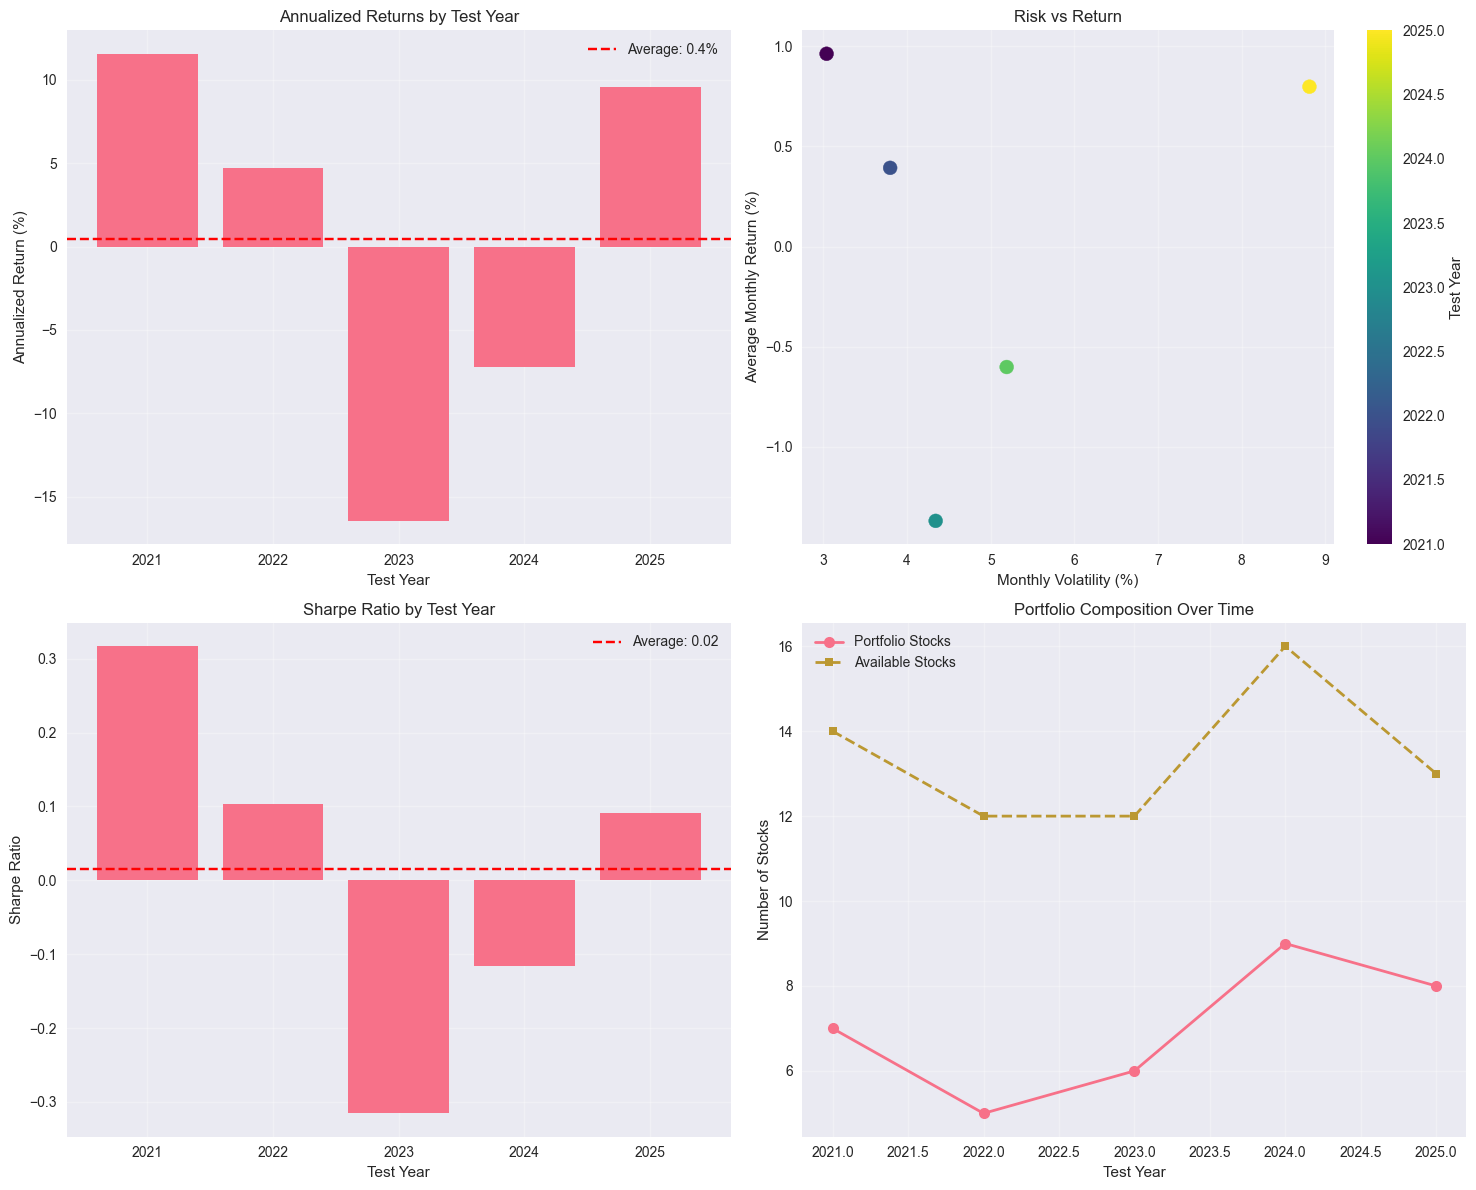


BACKTESTING SUMMARY STATISTICS

PERFORMANCE METRICS:
Average Annual Return: 0.44%
Average Monthly Volatility: 5.03%
Average Sharpe Ratio: 0.016
Best Year Return: 11.54% (2021)
Worst Year Return: -16.43% (2023)

PORTFOLIO CHARACTERISTICS:
Average Portfolio Size: 7.0 stocks
Average Available Stocks: 13.4 stocks
Portfolio Utilization: 52.2%

RISK METRICS:
Return Volatility: 11.92%
Success Rate (positive returns): 60.0%


In [16]:
# Run the complete backtesting analysis
print("Starting comprehensive backtesting analysis...")
print(f"Testing years: {CONFIG['test_start_year']} to {CONFIG['test_end_year']}")

# Run backtesting
results_df = run_backtesting(CONFIG['test_start_year'], CONFIG['test_end_year'])

if len(results_df) > 0:
    print(f"\nBacktesting completed! Results for {len(results_df)} years.")
    
    # Display results table
    display_df = results_df.copy()
    display_df['Avg_Monthly_Return'] = display_df['Avg_Monthly_Return'] * 100
    display_df['Total_Return'] = display_df['Total_Return'] * 100
    display_df['Volatility'] = display_df['Volatility'] * 100
    
    print("\nDetailed Results:")
    print(display_df.round(2).to_string(index=False))
    
    # Show visualizations
    if CONFIG['show_plots']:
        plot_backtesting_results(results_df)
    
else:
    print("No successful backtesting results obtained.")
    print("Please check your configuration parameters and data availability.")

## Current Portfolio Creation (Optional)

Create a portfolio for the current year using the latest available data.

In [17]:
# Create current portfolio
print("\n" + "="*60)
print("CREATING CURRENT PORTFOLIO")
print("="*60)

try:
    # Get recent data for current portfolio
    current_start = f"{CONFIG['current_year']-1}-12-01"
    current_end = f"{CONFIG['current_year']}-12-01"
    
    current_returns = get_stock_data(INDONESIA_BLUECHIP, current_start, current_end)
    
    if len(current_returns) > 0:
        # Filter positive return stocks
        current_positive_stocks = filter_positive_returns(current_returns)
        
        if len(current_positive_stocks) >= 2:
            current_filtered_returns = current_returns[current_positive_stocks]
            
            # Optimize current portfolio
            current_weights, current_stats = optimize_portfolio(current_filtered_returns)
            
            # Create current allocation
            current_allocation = create_portfolio_allocation(
                current_weights, current_positive_stocks, CONFIG['initial_capital']
            )
            
            print("\nCurrent Portfolio Allocation:")
            display_allocation = current_allocation.copy()
            display_allocation['Weight'] = display_allocation['Weight'].round(4)
            display_allocation['Actual_Weight'] = display_allocation['Actual_Weight'].round(4)
            print(display_allocation.to_string(index=False))
            
            # Save current portfolio
            if CONFIG['save_results']:
                current_allocation.to_csv(f'Current_Portfolio_{CONFIG["current_year"]}.csv', index=False)
                print(f"\nCurrent portfolio saved to Current_Portfolio_{CONFIG['current_year']}.csv")
        
        else:
            print("Insufficient stocks with positive returns for current portfolio")
    else:
        print("No current data available for portfolio creation")
        
except Exception as e:
    print(f"Error creating current portfolio: {e}")


CREATING CURRENT PORTFOLIO
Successfully downloaded 30 stocks
Filtered to 13 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 2.856%
Monthly risk (volatility): 5.024%
Sharpe ratio: 0.568
Successfully downloaded 30 stocks
Filtered to 13 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 2.856%
Monthly risk (volatility): 5.024%
Sharpe ratio: 0.568

Portfolio Allocation:
Total capital: IDR 30,000,000
Total invested: IDR 28,668,000
Cash remaining: IDR 1,332,000
Utilization: 95.6%

Current Portfolio Allocation:
  Stock  Weight  Target_Value  Price_Per_Share  Price_Per_Lot  Lots  Actual_Value  Actual_Weight
ASII.JK  0.3610  1.083006e+07           4950.0       495000.0    21    10395000.0         0.3465
ANTM.JK  0.1268  3.805179e+06           3040.0       304000.0    12     3648000.0         0.1216
KLBF.JK  0.0043  1.301012e+05           1495.0       149500.0     0           0.0         0.0000
CPIN.JK  0.1125  3.37382

## Configuration Tips and Next Steps

### How to Adjust Parameters:

1. **Change Testing Period**: Modify `test_start_year` and `test_end_year` in CONFIG
2. **Adjust Capital**: Change `initial_capital` for different investment amounts
3. **Risk Tolerance**: Adjust `max_weight_per_stock` to limit concentration
4. **Return Requirements**: Set `min_mean_return` to filter stocks
5. **Data Period**: Modify `training_period_months` for optimization window

### Performance Improvements:

- Add transaction costs
- Include dividend yields
- Implement rebalancing strategies
- Add more sophisticated risk measures
- Include market timing filters

### Data Quality:

- Monitor data availability warnings
- Consider alternative data sources
- Implement data quality checks
- Handle missing data more robustly